<a href="https://colab.research.google.com/github/pxtroniwnl/analisis-interpersonal-edo-nlp/blob/main/etl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga de Datos

In [43]:
import pandas as pd

# Definimos el separador extraño del dataset de Cornell
SEPARADOR_CORNELL = r' \+\+\+\$\+\+\+ '

# 1. Carga de movie_lines.txt (Contiene el texto de cada frase)
lines = pd.read_csv(
    'movie_lines.txt',
    sep=SEPARADOR_CORNELL,
    names=['lineID', 'characterID', 'movieID', 'characterName', 'text'],
    engine='python',
    encoding='latin-1'
)

# 2. Carga de movie_conversations.txt (Contiene la estructura de los diálogos)
conversations = pd.read_csv(
    'movie_conversations.txt',
    sep=SEPARADOR_CORNELL,
    names=['charID_1', 'charID_2', 'movieID', 'utteranceIDs'],
    engine='python',
    encoding='latin-1'
)

In [44]:
lines

,lineID,characterID,movieID,characterName,text
0,L1045,u0,m0,BIANCA,They do not!
1,L1044,u2,m0,CAMERON,They do to!
2,L985,u0,m0,BIANCA,I hope so.
3,L984,u2,m0,CAMERON,She okay?
4,L925,u0,m0,BIANCA,Let's go.
...,...,...,...,...,...
304708,L666371,u9030,m616,DURNFORD,Lord Chelmsford seems to want me to stay back ...
304709,L666370,u9034,m616,VEREKER,I'm to take the Sikali with the main column to...
304710,L666369,u9030,m616,DURNFORD,"Your orders, Mr Vereker?"
304711,L666257,u9030,m616,DURNFORD,"Good ones, yes, Mr Vereker. Gentlemen who can ..."


In [45]:
conversations

,charID_1,charID_2,movieID,utteranceIDs
0,u0,u2,m0,"['L194', 'L195', 'L196', 'L197']"
1,u0,u2,m0,"['L198', 'L199']"
2,u0,u2,m0,"['L200', 'L201', 'L202', 'L203']"
3,u0,u2,m0,"['L204', 'L205', 'L206']"
4,u0,u2,m0,"['L207', 'L208']"
...,...,...,...,...
83092,u9028,u9031,m616,"['L666324', 'L666325', 'L666326', 'L666327']"
83093,u9028,u9031,m616,"['L666575', 'L666576']"
83094,u9030,u9034,m616,"['L666256', 'L666257']"
83095,u9030,u9034,m616,"['L666369', 'L666370', 'L666371', 'L666372']"


Bueno ya tenemos nuestros datasets cargados pero nuestro objetivo lo que queremos es que estos dialogos y frases pasen a una forma numerica ya que asi como estan ahora no podemos usarlo para la ecuacion diferencial y el modelo de Gotman-Murray ya que lo que entra son numeros con una escala de -1 a 1 donde -1 seria muy malo y 1 muy malo por lo que haremos eso usando una tecnica de **Natural Language Processing (NLP)** llamada **Valence Aware Dictionary and sEntiment Reasoner (VADER)** Usaremos VADER porque esta tecnica tiene en cuenta los terminos coloquiales que se hacen en la pelicula

# VADER

Es una herramienta de análisis de sentimientos diseñada para analizar textos de redes sociales y lenguaje informal. A diferencia de los métodos tradicionales de análisis de sentimientos, es especialmente eficaz para detectar el sentimiento en textos cortos como tuits, reseñas de productos o comentarios de usuarios que contienen jerga, emojis y abreviaturas. Utiliza un léxico predefinido de palabras asociadas a valores de sentimiento y aplica reglas específicas para calcular las puntuaciones de sentimiento.

**VADER** funciona analizando la polaridad de las palabras las cuales a cada una se le asigna una puntuacion que va de -1 a 1 donde esa puntuacion esta asociada al posible sentimiento que quiere inspirar

- Puntuación compuesta > 0,05 : Sentimiento positivo
- Puntuación compuesta < -0,05 : Sentimiento negativo
- Puntuación compuesta entre -0,05 y 0,05 : Sentimiento neutral


In [46]:
!pip install nltk

In [47]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [48]:
sia = SentimentIntensityAnalyzer()

def obtener_humor(texto):
    if pd.isna(texto):
        return 0.0
    score = sia.polarity_scores(texto)
    return score['compound']

Ahora que ya tenemos la funcion para obtener el humor dependiendo de la frase que se ingrese como input de la funcion, y ademas tengo que generar ahora el humor para todas las frases en la columna que tiene las frases

In [49]:
lines["sentimiento"] = lines["text"].apply(obtener_humor)

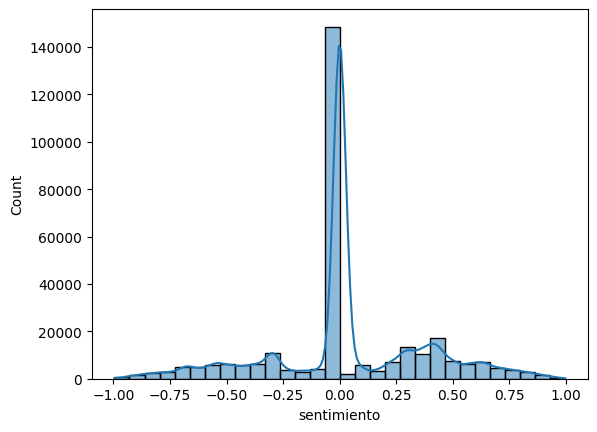

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=lines,x=lines["sentimiento"],bins=30,kde=True)
plt.show()

Vemos que la distribucion de los sentimientos de todas las conversaciones sigue una muy leptocurtica en 0 lo cual es normal ya que como sabemos no todos los dialogos o interacciones o frases dichas son diciendo cosas como "te amo" o "te odio" de hecho no suelen representar gran cantidad o gran parte de la pelicula, sino, por el contrario suele ser solo en momentos de **CLIMAX** o de **CONCLUSION** del arco narrativo por lo que la gran mayoria de dialogos no son emocionales sino **funcionales**, es decir, que no representan un sentimiento claro, sino que son neutrales y estos dialogos suele representar la mayor parte pero bueno a continuacion...

---

Ya sabemos que teemos el dataset y maneja esa distribucion los sentimientos, lo que ahora entendemos de esto es que el "ruido" informativo supera a la "señal" emocional. Para que un modelo de  Gottman-Murray no se rompa procesando tantos ceros, el paso a seguir es construirla serie de tiempo de forma estructurada:

1. Filtrado de "Parejas de Alto Drama": No todas las conversaciones del dataset sirven para una EDO. Necesitas "señal".

- Métrica: Calcula la Desviación Estándar ($\sigma$) del sentimiento por cada conversación.

- Accion: Nos quedaremos solo con las parejas que tenngan una desviacion estandar alta(es decir, donde el sentimiento varía mucho) y al menos que tengan un numero de 10 dialogos si la desviacion de la conversacion llegara a 0 sera una conversacioon aburrida que no aportara nada al modelo al menos no a estabilizarse ya que para ello podemos usar filtros que suavizan la serie de tiempo del sentimiento

In [51]:
import ast
conversations['utteranceIDs'] = conversations['utteranceIDs'].apply(ast.literal_eval)

In [52]:
#Primero debemos revisar cuantas lineas tiene cada conversacion para poder filtrar solo las de mas de 10 lineas
conversations['num_lines'] = conversations['utteranceIDs'].apply(len)
convs_largas = conversations[conversations['num_lines'] >= 10].copy()

In [53]:
convs_largas

,charID_1,charID_2,movieID,utteranceIDs,num_lines
138,u5,u9,m0,"[L626, L627, L628, L629, L630, L631, L632, L63...",11
153,u5,u9,m0,"[L813, L814, L815, L816, L817, L818, L819, L82...",11
168,u5,u11,m0,"[L338, L339, L340, L341, L342, L343, L344, L34...",10
286,u16,u22,m1,"[L2196, L2197, L2198, L2199, L2200, L2201, L22...",16
298,u26,u30,m2,"[L3464, L3465, L3466, L3467, L3468, L3469, L34...",18
...,...,...,...,...,...
82931,u9015,u9017,m615,"[L665492, L665493, L665494, L665495, L665496, ...",12
82932,u9015,u9017,m615,"[L665506, L665507, L665508, L665509, L665510, ...",10
82964,u9017,u9019,m615,"[L665530, L665531, L665532, L665533, L665534, ...",10
82983,u9017,u9019,m615,"[L665726, L665727, L665728, L665729, L665730, ...",11


In [54]:
#Creamos una funcion para calcular la variacion
def calcular_variacion(lista_ids):
    sentimientos = lines[lines['lineID'].isin(lista_ids)]['sentimiento']
    return sentimientos.std()

In [55]:
convs_largas['variacion_emocional'] = convs_largas['utteranceIDs'].apply(calcular_variacion)
mejores_convs = convs_largas.sort_values(by=['variacion_emocional', 'num_lines'], ascending=False)

In [56]:
mejores_convs

,charID_1,charID_2,movieID,utteranceIDs,num_lines,variacion_emocional
66523,u7259,u7263,m490,"[L467965, L467966, L467967, L467968, L467969, ...",10,0.746877
76696,u8329,u8332,m565,"[L598414, L598415, L598416, L598417, L598418, ...",10,0.668868
66058,u7220,u7227,m487,"[L459944, L459945, L459946, L459947, L459948, ...",11,0.646501
17608,u1891,u1893,m124,"[L357284, L357285, L357286, L357287, L357288, ...",13,0.624026
66062,u7220,u7227,m487,"[L459991, L459992, L459993, L459994, L459995, ...",13,0.621561
...,...,...,...,...,...,...
59707,u6523,u6527,m433,"[L372839, L372840, L372841, L372842, L372843, ...",11,0.000000
75984,u8240,u8248,m560,"[L585929, L585930, L585931, L585932, L585933, ...",11,0.000000
17469,u1872,u1888,m123,"[L355933, L355934, L355935, L355936, L355937, ...",10,0.000000
40667,u4331,u4365,m289,"[L121039, L121040, L121041, L121042, L121043, ...",10,0.000000


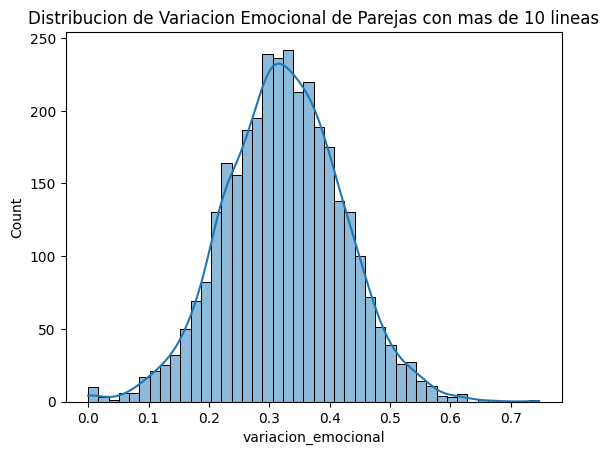

In [59]:
import seaborn as sns

sns.histplot(data=mejores_convs,x="variacion_emocional",kde=True)
plt.title("Distribucion de Variacion Emocional de Parejas con mas de 10 lineas")
plt.show()

In [60]:
mejores_convs["variacion_emocional"].describe()

,variacion_emocional
count,3291.000000
mean,0.323902
std,0.096755
min,0.000000
25%,0.260590
50%,0.323791
75%,0.387380
max,0.746877


Ahora que vemos la variacion emocional tambien sigue una campana de gauss o algo parecido sabemos que queremos cojer las conversaciones que esten alrededor de 0.3 o 0.4 en adelante de variacion emocional ya que estas son las parejas que realmente presentan ¡drama! lo que nos interesa...

---
2. Creación de la Serie Temporal Acoplada

Lo proximo de eso es hacer la serie temporal de la pareja ya que queremos que quede como una tabla donde esté el tiempo y las 2 series de tiempos de las 2 ecuaciones acopladas, algo así...

| Tiempo ($t$) | Personaje A ($W_t$) | Personaje B ($H_t$) |
| :--- | :--- | :--- |
| 1 | 0.5 (A inicia feliz) | NaN (B aún no habla) |
| 2 | NaN | -0.2 (B responde cortante) |
| 3 | 0.1 (A se desinfla) | NaN |

Creemos una funcion que saque la linea temporal de una sola conversacion para ver como la hace y ya luego generalizamos

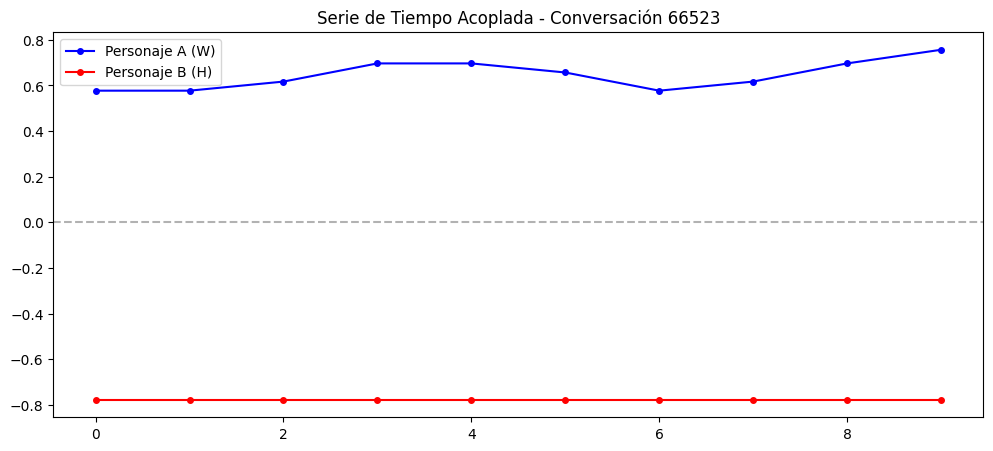

In [63]:
# 1. Obtenemos el ID real de la conversación más movidam

id_real = mejores_convs.index[0]
import numpy as np

def preparar_serie_edo_v2(conv_id, df_convs, df_lines):
    # Extraer los IDs de las frases de esa conversación específica
    ids_frases = df_convs.loc[conv_id, 'utteranceIDs']
    c1 = df_convs.loc[conv_id, 'charID_1']
    c2 = df_convs.loc[conv_id, 'charID_2']

    # Extraer y ordenar las líneas
    dialogo = df_lines[df_lines['lineID'].isin(ids_frases)].copy()

    # Es vital mantener el orden de la lista de IDs original
    dialogo['lineID'] = pd.Categorical(dialogo['lineID'], categories=ids_frases, ordered=True)
    dialogo = dialogo.sort_values('lineID')

    # Crear la estructura de tiempo
    df_serie = pd.DataFrame({'t': range(len(dialogo))})

    # Asignar sentimientos según el personaje
    df_serie['W'] = [row['sentimiento'] if row['characterID'] == c1 else np.nan for _, row in dialogo.iterrows()]
    df_serie['H'] = [row['sentimiento'] if row['characterID'] == c2 else np.nan for _, row in dialogo.iterrows()]

    # Llenar huecos e interpolar para tener curvas continuas
    # Primero interpolamos linealmente, luego rellenamos los extremos (bfill/ffill)
    df_serie['W_cont'] = df_serie['W'].interpolate(limit_direction='both')
    df_serie['H_cont'] = df_serie['H'].interpolate(limit_direction='both')

    # Suavizado para que las EDOs no se vuelvan locas con picos
    df_serie['W_suave'] = df_serie['W_cont'].rolling(window=3, center=True, min_periods=1).mean()
    df_serie['H_suave'] = df_serie['H_cont'].rolling(window=3, center=True, min_periods=1).mean()

    return df_serie

# Generar y graficar
datos_finales = preparar_serie_edo_v2(id_real, mejores_convs, lines)

if datos_finales.empty or datos_finales['W_suave'].isnull().all():
    print("Error: Los datos siguen vacíos. Revisa si 'lines' tiene sentimientos calculados.")
else:
    plt.figure(figsize=(12, 5))
    plt.plot(datos_finales['t'], datos_finales['W_suave'], label='Personaje A (W)', color='blue', marker='o', markersize=4)
    plt.plot(datos_finales['t'], datos_finales['H_suave'], label='Personaje B (H)', color='red', marker='o', markersize=4)
    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.title(f"Serie de Tiempo Acoplada - Conversación {id_real}")
    plt.legend()
    plt.show()

---

3. Suavizado (Smoothing) mediante Media Móvil


Como la grafica tendrá muchos ceros, la EDO va a saltar de forma muy brusca, pero para que la curva sea derivable y suave probablemente tedremos que aplicar una media movil ponderada

- Si el Personaje A dijo algo triste en $t=1$, su estado en $t=2$ probablemente siga siendo triste aunque su frase sea neutra.

- Usaremos .rolling(window=3, win_type='gaussian').mean() en Pandas para suavizar los picos y valles.


---

4. El "Interpolado" (Llenado de Huecos)

Las EDOs necesitan que ambas variables ($W$ y $H$) tengan valores en cada punto del tiempo para calcular la interacción.

- Accion: Necesitaremos interpolar en algunos puntos de tiempo ya que hay momentos o intervalos de tiempo donde un personaje A esta hablando pero el B no por lo que tendremos que suponer que en ese intervalo de tiempo probablemente el personaje que no está hablando se quedo con la mismo emocion que tenia justo antes de que hablara el otro